Description - Toy data set generated by sampling 20 inputs x
uniformly at random in the interval [−4, 4]. For each
value of x obtained, the corresponding target y is computed as y = x
3 + n, where n ∼ N (0, 9). We fitted a
neural network with one layer and 100 hidden units

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

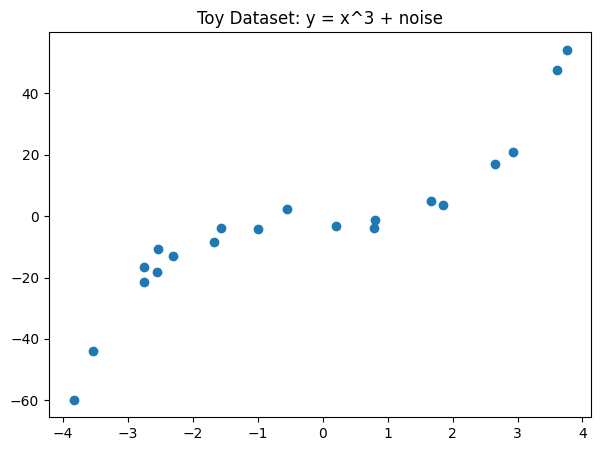

In [35]:
torch.manual_seed(42)
np.random.seed(42)
N = 20

x = np.random.uniform(-4, 4, N)
noise = np.random.normal(0, 3, N)

y = x**3 + noise

X = torch.tensor(x,dtype=torch.float32).unsqueeze(1)
Y = torch.tensor(y,dtype=torch.float32).unsqueeze(1)

x_test = np.linspace(-6,6,400)
X_test = torch.tensor(x_test,dtype=torch.float32).unsqueeze(1)

plt.figure(figsize=(7,5))
plt.scatter(x, y)
plt.title("Toy Dataset: y = x^3 + noise")
plt.show()

In [37]:
class MSENet(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,100),
            nn.ReLU(),
            nn.Linear(100,1)
        )

    def forward(self,x):
        return self.net(x)


In [45]:
num_models = 5
num_epochs = 10000
lr = 1e-3
mse_models = []

for n in range(num_models):
    m = MSENet()
    opt = optim.Adam(m.parameters(),lr=lr)
    for ep in range(num_epochs):
        opt.zero_grad()
        loss = nn.MSELoss()(m(X),Y)
        loss.backward()
        opt.step()
    mse_models.append(m)

predictions = np.array([m(X_test).detach().numpy() for m in mse_models]).squeeze()
mse_mean = predictions.mean(0)
mse_std = predictions.std(0)

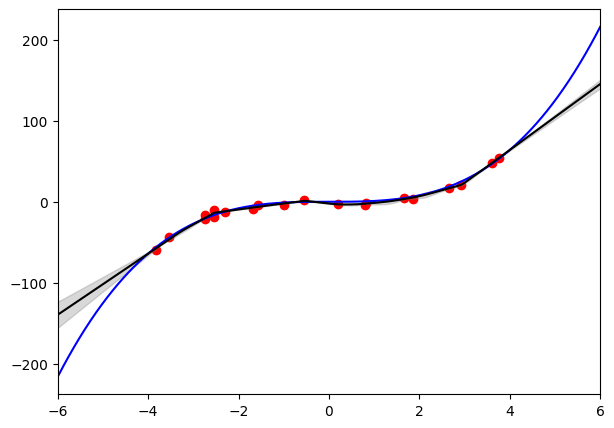

In [46]:
plt.figure(figsize=(7,5))
plt.scatter(x,y,color="red")
plt.plot(x_test,x_test**3,color="blue")
plt.plot(x_test,mse_mean,color="black")
plt.fill_between(x_test,mse_mean-3*mse_std,mse_mean+3*mse_std, color="gray",alpha=0.3)
plt.xlim(-6,6)
plt.show()